In [1]:
import json
path = "/home/jma/Documents/medvlm3d/AMOSMM_dataset.json"
with open(path) as f:
    data = json.load(f)

all = data['training'] + data['validation']    

regions = ['Pelvis', 'Chest', 'Abdomen']
min_words = []
avg_words = []
max_words = []
findings_present = []

for region in regions:
    word_counts = []
    findings_count = 0
    total_count = 0
    
    for entry in all:
        findings = entry['labels']['report']['findings'].get(region.lower(), '')
        total_count += 1
        if findings:
            findings_count += 1
            word_counts.append(len(findings.split()))
    
    findings_present.append((findings_count / total_count) * 100 if total_count > 0 else 0)
    
    if word_counts:
        min_words.append(min(word_counts))
        avg_words.append(sum(word_counts) / len(word_counts))
        max_words.append(max(word_counts))
    else:
        min_words.append(0)
        avg_words.append(0)
        max_words.append(0)


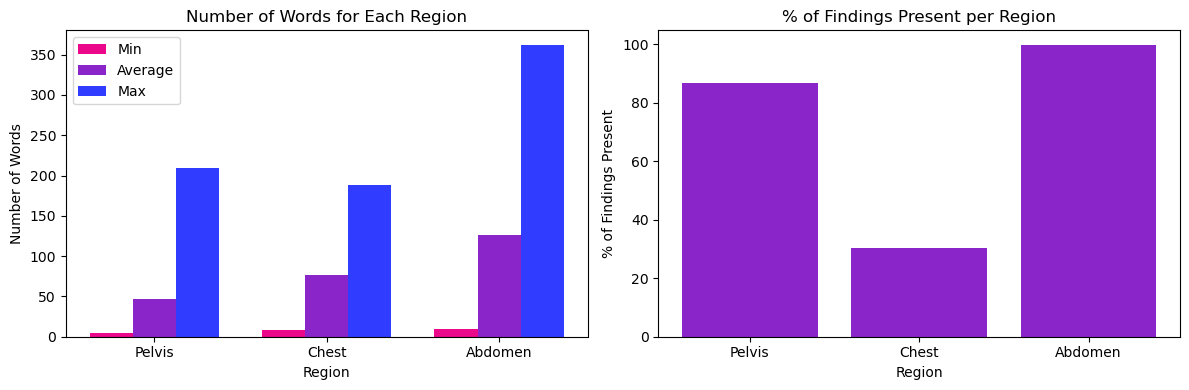

In [31]:
import matplotlib.pyplot as plt
import numpy as np


fig, axs = plt.subplots(1, 2, figsize=(12, 4))

bar_width = 0.25
index = np.arange(len(regions))

axs[0].bar(index, min_words, bar_width, label='Min', color='#eb088aff')
axs[0].bar(index + bar_width, avg_words, bar_width, label='Average', color='#8a25c9ff')
axs[0].bar(index + 2 * bar_width, max_words, bar_width, label='Max', color='#303cffff')

axs[0].set_title('Number of Words for Each Region')
axs[0].set_xlabel('Region')
axs[0].set_ylabel('Number of Words')
axs[0].set_xticks(index + bar_width)
axs[0].set_xticklabels(regions)
axs[0].legend()

axs[1].bar(regions, findings_present, color='#8a25c9ff')
axs[1].set_title('% of Findings Present per Region')
axs[1].set_xlabel('Region')
axs[1].set_ylabel('% of Findings Present')

plt.tight_layout()
# output_path = '/mnt/data/fake_data_figure.png'
# plt.savefig(output_path)
# plt.close()
plt.show()